# Natural Movie Subpopulation Analysis

Analyses neural trajectory structure and frame decodability for natural movie responses (VISp, Allen Brain Observatory).
Subpopulations are defined by one of three methods: neuron metric percentiles (reliability / speed / selectivity), bounding-box regions in the precomputed encoding manifold, or HDBSCAN clusters of response patterns.

movie frame coherent segments

0 - 13 (linear movement)
13 - 53 (stable)
53 - 110 (man to left)
110 - 134 (stable)
134 - 161 (man to right + pan to right)
161 - 183 (pan to right)
183 - 205 (shadow to right + pan to right)
205 - 324 (pan to right)
324 - 412 (zoom)
412 - 424 (man to right)
424 - 474 (pan car)
474 - 630 (couple to car)
630 - 780 (stable)
780 - 900 (car + pan)




## Section 0 — Setup

In [32]:
import os
import numpy as np
import matplotlib.pyplot as plt

NV_DIR = os.path.dirname(os.path.abspath('07_natural_video.ipynb'))  # = notebooks/
import sys, os; _d = os.path.abspath(os.getcwd()); sys.path.insert(0, _d if os.path.isdir(os.path.join(_d, 'src')) else os.path.dirname(_d))
import src.natural_video_utils as nv

In [33]:
# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
DATA_DIR   = os.path.join(NV_DIR, '..', 'data', 'natural_video')  # data/natural_video/
ENC_MFD_DIR = os.path.join(NV_DIR, '..', 'data', 'natural_video')
FIG_DIR    = os.path.join(NV_DIR, '../fig', 'subpop_analysis')
os.makedirs(FIG_DIR, exist_ok=True)

AREA      = 'VISp'
STIMULUS  = 'natural_movie_one'
N_PCA     = 3

MY_SESSION_IDS = [
    719161530, 737581020, 746083955, 798911424, 743475441, 744228101, 756029989, 758798717,
    715093703, 762602078, 797828357, 754312389, 760345702, 739448407, 763673393, 799864342,
    721123822, 761418226, 732592105, 742951821, 762120172, 750749662, 791319847, 760693773,
    755434585, 759883607, 750332458, 757216464, 754829445, 757970808, 773418906, 751348571,
]

# ---------------------------------------------------------------------------
# Hand-labelled movie segments  (start inclusive, end exclusive)
# ---------------------------------------------------------------------------
SCENE_SEGMENTS = [
    (0,   13,  'linear movement'),
    (13,  53,  'stable'),
    (53,  110, 'man to left'),
    (110, 134, 'stable'),
    (134, 161, 'man to right + pan to right'),
    (161, 183, 'pan to right'),
    (183, 205, 'shadow to right + pan to right'),
    (205, 324, 'pan to right'),
    (324, 412, 'zoom'),
    (412, 424, 'man to right'),
    (424, 474, 'pan car'),
    (474, 630, 'couple to car'),
    (630, 780, 'stable'),
    (780, 900, 'car + pan'),
]
CLIP_LEN = 20  # frames taken from the start of each qualifying segment

# Segments with >= CLIP_LEN frames (used for tensor option 3 and trace annotations)
LONG_SEGMENTS = [(s, e, lbl) for s, e, lbl in SCENE_SEGMENTS if (e - s) >= CLIP_LEN]
SCENE_STARTS  = [s for s, e, lbl in LONG_SEGMENTS]   # for trace annotations
print(f'{len(LONG_SEGMENTS)} segments with >= {CLIP_LEN} frames: starts = {SCENE_STARTS}')

12 segments with >= 20 frames: starts = [13, 53, 110, 134, 161, 183, 205, 324, 424, 474, 630, 780]


In [34]:
trial_avgs, all_neurons, session_uids_used = nv.load_natural_movie_data(
    DATA_DIR, MY_SESSION_IDS, area=AREA, stimulus=STIMULUS
)
print(f'trial_avgs: {trial_avgs.shape}   all_neurons: {all_neurons.shape}')

  719161530 — 52 units
  737581020 — 40 units
  746083955 — 14 units
  798911424 — 94 units
  743475441 — 45 units
  744228101 — 35 units
  756029989 — 51 units
  758798717 — 47 units
  715093703 — 60 units
  762602078 — 75 units
  797828357 — 85 units
  754312389 — 102 units
  760345702 — 72 units
  739448407 — 19 units
  763673393 — 73 units
  799864342 — 75 units
  721123822 — 41 units
  761418226 — 36 units
  732592105 — 110 units
  742951821 — 33 units
  762120172 — 84 units
  750749662 — 52 units
  791319847 — 93 units
  760693773 — 88 units
  755434585 — 75 units
  759883607 — 58 units
  750332458 — 63 units
  757216464 — 85 units
  754829445 — 92 units
  757970808 — 80 units
  773418906 — 37 units
  751348571 — 49 units
Loaded 2015 neurons, 900 frames
trial_avgs: (2015, 900)   all_neurons: (2015, 20, 900)


## Save tensor4d

Three encodings of the natural movie data in `(neurons, stimuli, directions=1, time)` format:

| Option | Shape | Stimuli | Time | Comment |
|--------|-------|---------|------|---------|
| 1 | `(N, 900, 1, 1)` | 900 frames | 1 | Frame-level geometry; no temporal dynamics |
| 2 | `(N, 1, 1, 900)` | 1 movie | 900 | Full timeline but trivial stimulus mode |
| 3 | `(N, K, 1, 20)` | K hand-labelled scenes | 20 | Scene-structured; best analogy to grating tensors |

**Recommendation — Option 3.**
The CP decomposition factorises `(neurons × stimuli × time)`.  Options 1 and 2 each collapse one of these modes: option 1 has no temporal structure (T=1), option 2 has no stimulus structure (S=1), so in both cases one factor is trivially uninformative.  Option 3 preserves both axes: the 12 semantically distinct scene conditions play the role of grating directions/frequencies, and the 20-frame window captures within-scene dynamics — exactly mirroring the biological data structure `(N, 6 SFs, 8 dirs, 135 frames)`.  The neuron factor will then separate cells by scene preference, while the time factor captures the response trajectory shape within a scene.  One caveat: 12 scenes is fewer conditions than typical grating experiments, so the stimulus factor may be noisier — more scenes would help if additional hand-labelled segments become available.

In [35]:
SAMPLED_DIR = os.path.normpath(os.path.join(NV_DIR, '..', 'data', 'sampled'))
N = trial_avgs.shape[0]

# Dummy neurons_used array: (N, 5) int64, sequential neuron index in last column
neurons_used_dummy = np.zeros((N, 5), dtype=np.int64)
neurons_used_dummy[:, 4] = np.arange(N)

# --- Option 1: (N, 900, 1, 1)  — each frame is a separate stimulus, T=1 ---
t4d_frames = trial_avgs[:, :, np.newaxis, np.newaxis]
path1 = os.path.join(SAMPLED_DIR, 'tensor4d_VISp_natural_movie_one_frames.npy')
np.save(path1, t4d_frames)
np.save(path1.replace('tensor4d_', 'neurons_used_'), neurons_used_dummy)
print(f'Option 1  {t4d_frames.shape}  → {os.path.basename(path1)}')

# --- Option 2: (N, 1, 1, 900)  — single stimulus, T=900 ---
t4d_single = trial_avgs[:, np.newaxis, np.newaxis, :]
path2 = os.path.join(SAMPLED_DIR, 'tensor4d_VISp_natural_movie_one_single.npy')
np.save(path2, t4d_single)
np.save(path2.replace('tensor4d_', 'neurons_used_'), neurons_used_dummy)
print(f'Option 2  {t4d_single.shape}  → {os.path.basename(path2)}')

# --- Option 3: (N, K, 1, CLIP_LEN)  — K hand-labelled scenes × 20-frame window ---
clips = np.stack(
    [trial_avgs[:, s : s + CLIP_LEN] for s, e, lbl in LONG_SEGMENTS],
    axis=1,
)  # (N, K, CLIP_LEN)
t4d_scenes = clips[:, :, np.newaxis, :]   # (N, K, 1, CLIP_LEN)
path3 = os.path.join(SAMPLED_DIR, f'tensor4d_VISp_natural_movie_one_scenes{CLIP_LEN}.npy')
np.save(path3, t4d_scenes)
np.save(path3.replace('tensor4d_', 'neurons_used_'), neurons_used_dummy)
print(f'Option 3  {t4d_scenes.shape}  → {os.path.basename(path3)}')
print(f'  Scenes: {[(s, lbl) for s, e, lbl in LONG_SEGMENTS]}')

Option 1  (2015, 900, 1, 1)  → tensor4d_VISp_natural_movie_one_frames.npy
Option 2  (2015, 1, 1, 900)  → tensor4d_VISp_natural_movie_one_single.npy
Option 3  (2015, 12, 1, 20)  → tensor4d_VISp_natural_movie_one_scenes20.npy
  Scenes: [(13, 'stable'), (53, 'man to left'), (110, 'stable'), (134, 'man to right + pan to right'), (161, 'pan to right'), (183, 'shadow to right + pan to right'), (205, 'pan to right'), (324, 'zoom'), (424, 'pan car'), (474, 'couple to car'), (630, 'stable'), (780, 'car + pan')]


In [36]:
enc_embedding, cell_ids = nv.load_encoding_manifold(ENC_MFD_DIR)
nm2m, m2nm = nv.build_index_maps(session_uids_used, cell_ids)

# All natural-movie indices that have a manifold counterpart
all_shared_nm_idxs = sorted(nm2m.keys())
all_shared_m_idxs  = [nm2m[i] for i in all_shared_nm_idxs]

Encoding manifold: 1261 neurons, 6 dims
Shared neurons: 1261 of 2015 nat-movie, 1261 of 1261 manifold


## Section 1 — Full Population Trajectory

In [37]:
avg_traj, pca_full = nv.compute_population_trajectory(trial_avgs, n_components=N_PCA)
print(f'avg_traj: {avg_traj.shape}  explained variance: {pca_full.explained_variance_ratio_.round(3)}')

/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:374: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:374: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:374: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:375: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:375: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-

avg_traj: (900, 3)  explained variance: [0.135 0.091 0.056]


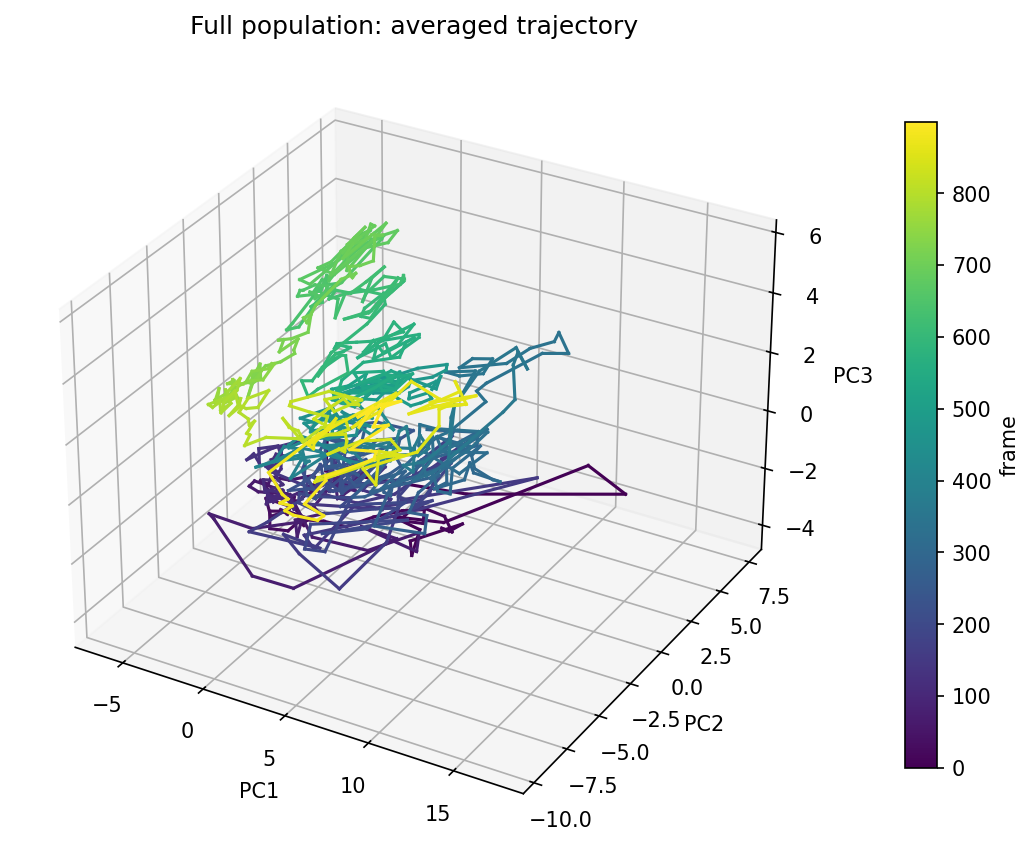

In [38]:
fig = nv.plot_single_trajectory(
    avg_traj,
    title='Full population: averaged trajectory',
    out_path=os.path.join(FIG_DIR, 'full_pop_avg_traj.png'),
)
plt.show()

In [39]:
bundle_full, trial_mask_full = nv.compute_trial_bundle(all_neurons, pca_full)
print(f'bundle_full: {bundle_full.shape}  valid trials: {trial_mask_full.sum()}')

bundle_full: (20, 900, 3)  valid trials: 20


/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/johannesbertram/repos/FNN_Manifolds/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: overflow encountered in matmul
  X_transforme

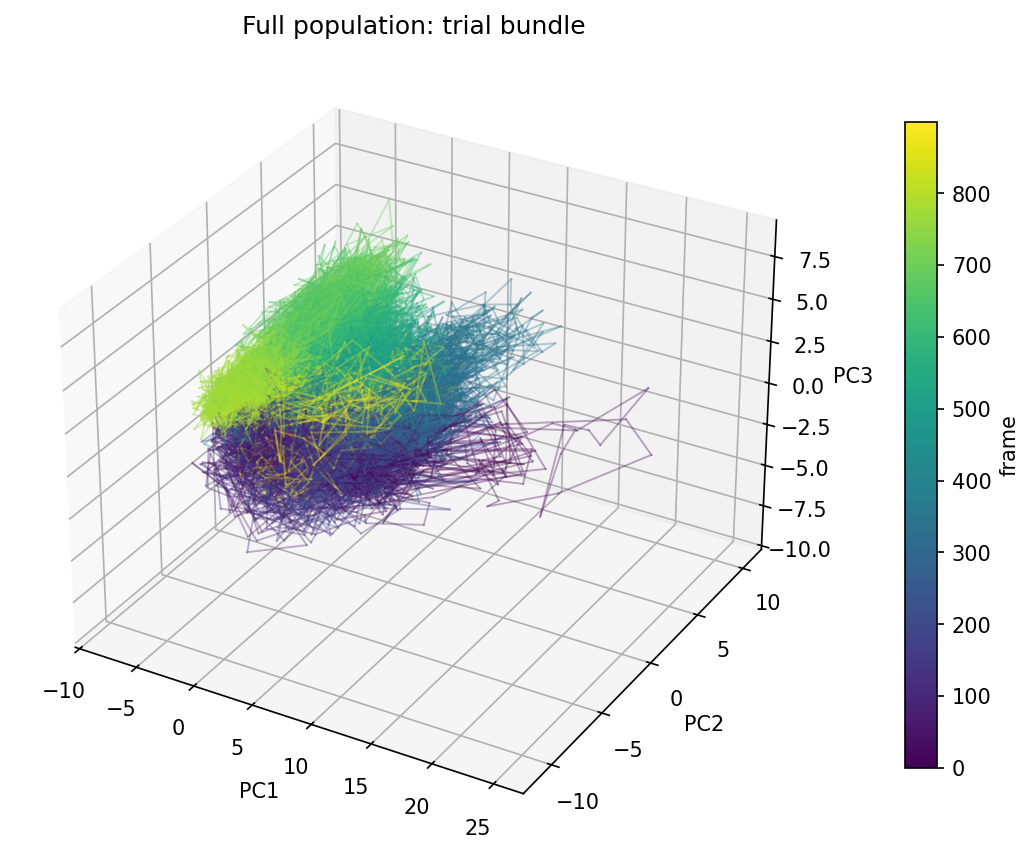

In [40]:
fig = nv.plot_trial_bundle(
    bundle_full,
    title='Full population: trial bundle',
    out_path=os.path.join(FIG_DIR, 'full_pop_trial_bundle.png'),
)
plt.show()

## Section 2 — Neuron Metrics

In [41]:
metrics = nv.compute_neuron_metrics(all_neurons, trial_avgs)
for k, v in metrics.items():
    finite = np.isfinite(v)
    print(f"{k:20s}  mean={np.nanmean(v):.4f}  std={np.nanstd(v):.4f}  finite={finite.sum()}/{len(v)}")

KeyboardInterrupt: 

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3), dpi=120)
for ax, (name, vals) in zip(axes, metrics.items()):
    finite_vals = vals[np.isfinite(vals)]
    ax.hist(finite_vals, bins=40, color='steelblue', alpha=0.8, edgecolor='none')
    ax.set_xlabel(name)
    ax.set_ylabel('count')
    ax.set_title(name)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'metric_histograms.png'), bbox_inches='tight')
plt.show()

In [ ]:
# Map each metric onto the encoding manifold
for metric_name in ['reliability', 'speed', 'selectivity']:
    fig = nv.plot_metric_on_manifold(
        enc_embedding, nm2m, metrics[metric_name], metric_name,
        out_path=os.path.join(FIG_DIR, f'manifold_{metric_name}.png'),
    )
    plt.show()

## Section 3 — Neuron Clustering (HDBSCAN)

In [ ]:
cluster_labels, embedding_2d = nv.cluster_neurons_by_response(
    trial_avgs, n_pcs=20, min_cluster_size=10
)
unique_clusters = sorted(c for c in set(cluster_labels) if c != -1)
print(f'Clusters: {unique_clusters}')

In [ ]:
fig = nv.plot_cluster_embedding(
    embedding_2d, cluster_labels,
    out_path=os.path.join(FIG_DIR, 'cluster_embedding.png'),
)
plt.show()

In [ ]:
# For each cluster: show where it sits on the encoding manifold
for c in unique_clusters:
    cluster_nm_idxs = list(np.where(cluster_labels == c)[0])
    cluster_m_idxs  = nv.natmovie_to_manifold_indices(cluster_nm_idxs, nm2m)
    if len(cluster_m_idxs) == 0:
        print(f'Cluster {c}: no shared neurons with manifold')
        continue
    fig = nv.plot_manifold_with_highlighted_subpop(
        enc_embedding, all_shared_m_idxs, cluster_m_idxs,
        out_path=os.path.join(FIG_DIR, f'manifold_cluster{c}.png'),
    )
    fig.suptitle(f'Cluster {c} (n={len(cluster_nm_idxs)}, matched={len(cluster_m_idxs)})', y=1.01)
    plt.show()

In [ ]:
# For each cluster: compute avg trajectory projected onto full-pop PCA axes
cluster_traj_dict = {}
for c in unique_clusters:
    cluster_nm_idxs = np.where(cluster_labels == c)[0]
    traj_c, _ = nv.compute_population_trajectory(
        trial_avgs[cluster_nm_idxs], pca=pca_full, neuron_indices=cluster_nm_idxs
    )
    cluster_traj_dict[c] = traj_c
    print(f'Cluster {c}: {len(cluster_nm_idxs)} neurons')

## Section 4 — Subpopulation Selection

### 4a — By metric (top 20% reliability)

In [ ]:
subpop_idxs = nv.select_by_metric(metrics, 'speed', percentile_lo=95)
print(f'Subpop (speed > p95): {len(subpop_idxs)} neurons')

### 4b — By encoding manifold region (optional)
Uncomment to select neurons from a bounding-box region in manifold space.

In [ ]:
# # Example: select neurons in a bounding box of the first two manifold dimensions
# dc1_lo, dc1_hi = -5.0, 0.0
# dc2_lo, dc2_hi = -2.0, 2.0
# bbox_mask = (
#     (enc_embedding[:, 0] >= dc1_lo) & (enc_embedding[:, 0] <= dc1_hi) &
#     (enc_embedding[:, 1] >= dc2_lo) & (enc_embedding[:, 1] <= dc2_hi)
# )
# manifold_idxs = list(np.where(bbox_mask)[0])
# subpop_idxs = np.array(nv.manifold_to_natmovie_indices(manifold_idxs, m2nm))
# print(f'Subpop (manifold bbox): {len(subpop_idxs)} neurons')

## Section 5 — Subpopulation Trajectory

In [ ]:
# Project subpop onto full-pop PCA axes for direct comparison.
# neuron_indices tells the function which columns of pca_full to use.
subpop_avg_traj, _ = nv.compute_population_trajectory(
    trial_avgs[subpop_idxs], pca=pca_full, neuron_indices=subpop_idxs
)
print(f'subpop_avg_traj: {subpop_avg_traj.shape}')

In [ ]:
fig = nv.plot_trajectory_comparison(
    avg_traj, subpop_avg_traj,
    title_full='Full population',
    title_sub='High-speed subpop (5%)',
    out_path=os.path.join(FIG_DIR, 'trajectory_comparison.png'),
)
plt.show()

In [ ]:
bundle_sub, trial_mask_sub = nv.compute_trial_bundle(
    all_neurons[subpop_idxs], pca_full, neuron_indices=subpop_idxs
)
print(f'bundle_sub: {bundle_sub.shape}  valid trials: {trial_mask_sub.sum()}')

In [ ]:
fig = nv.plot_trial_bundle_comparison(
    bundle_full, bundle_sub,
    out_path=os.path.join(FIG_DIR, 'trial_bundle_comparison.png'),
)
plt.show()

## Section 6 — Encoding Manifold Annotation

In [ ]:
# Build matched (nm_idx, m_idx, reliability) triples — preserving correspondence
subpop_m_idxs = []
subpop_rel_vals = []
for nm_i in subpop_idxs:
    if nm_i in nm2m:
        subpop_m_idxs.append(nm2m[nm_i])
        subpop_rel_vals.append(metrics['reliability'][nm_i])
subpop_rel_vals = np.array(subpop_rel_vals)
print(f'Subpop neurons on manifold: {len(subpop_m_idxs)}')

fig = nv.plot_manifold_with_highlighted_subpop(
    enc_embedding, all_shared_m_idxs, subpop_m_idxs,
    color_values=subpop_rel_vals,
    out_path=os.path.join(FIG_DIR, 'manifold_subpop_reliability.png'),
)
plt.show()

## Section 7 — Frame Decodability

In [ ]:
dec_full = nv.compute_frame_decodability(trial_avgs, n_neighbors=5)
dec_sub  = nv.compute_frame_decodability(trial_avgs[subpop_idxs], n_neighbors=5)

print(f"Full pop  R²={dec_full['r2']:.3f}  MAE={dec_full['mae']:.1f} frames")
print(f"Subpop    R²={dec_sub['r2']:.3f}  MAE={dec_sub['mae']:.1f} frames")

In [ ]:
fig = nv.plot_frame_decodability_comparison(
    {'full pop': dec_full, 'subpop': dec_sub},
    out_path=os.path.join(FIG_DIR, 'frame_decodability_comparison.png'),
)
plt.show()

In [ ]:
# Predicted vs true scatter
fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=120)
for ax, (label, res) in zip(axes, [('full pop', dec_full), ('subpop', dec_sub)]):
    ax.scatter(res['true_frames'], res['predictions'], s=4, alpha=0.4, color='steelblue')
    mn, mx = res['true_frames'].min(), res['true_frames'].max()
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1)
    ax.set_xlabel('true frame')
    ax.set_ylabel('predicted frame')
    ax.set_title(f"{label}  R²={res['r2']:.3f}")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'decodability_scatter.png'), bbox_inches='tight')
plt.show()

## Section 8 — Neuron-Level Traces

In [ ]:
# Load movie frames for scene context
movie_frames = np.load(os.path.join(NV_DIR, '../data/natural_video/movie1.npy'))  # (900, H, W)

# Use hand-labelled scene starts (segments with >= CLIP_LEN frames)
print(f'Scene starts: {SCENE_STARTS}')

# Plot top-10 reliability neurons with hand-labelled scene annotations
top10_idxs = list(subpop_idxs[:10])
fig = nv.plot_neuron_traces(
    trial_avgs[top10_idxs],
    neuron_idxs=top10_idxs,
    movie_frames=movie_frames,
    scene_starts=SCENE_STARTS,
    out_path=os.path.join(FIG_DIR, 'neuron_traces_top10.png'),
)
plt.show()

In [ ]:
## Section 9 — Scene Start Frames

import math

# Same grid layout as _plot_averaged_psths in explorer_utils.py
n_scenes = len(LONG_SEGMENTS)
ncols = min(n_scenes, 3)
nrows = math.ceil(n_scenes / ncols)

fig, axs = plt.subplots(nrows, ncols, figsize=(2.5 * ncols, 2.5 * nrows), squeeze=False)

for idx, (start, end, label) in enumerate(LONG_SEGMENTS):
    ax = axs[idx // ncols, idx % ncols]
    ax.imshow(movie_frames[start], cmap='gray', aspect='auto', interpolation='nearest')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f'f{start}: {label}', fontsize=7)

# Hide any unused axes
for idx in range(n_scenes, nrows * ncols):
    axs[idx // ncols, idx % ncols].set_visible(False)

fig.suptitle('Scene start frames', fontsize=10)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'scene_start_frames.png'), bbox_inches='tight', dpi=150)
plt.show()


## Section 10 — 3D Trajectory Panels (full trajectory + clip segments, all neurons + subpop)

In [ ]:
from matplotlib.lines import Line2D

# ── Subpopulation override ────────────────────────────────────────────────────
# CUSTOM_SUBPOP_IDXS was derived from the HDBSCAN clustering in Section 3.
# To regenerate it from a specific cluster, use:
#   TARGET_CLUSTER = <cluster_id_from_Section_3>
#   CUSTOM_SUBPOP_IDXS = list(np.where(cluster_labels == TARGET_CLUSTER)[0])
# Set to None to fall back to the metric-based subpop from Section 4.
CUSTOM_SUBPOP_IDXS = [3, 25, 54, 62, 96, 101, 132, 133, 140, 145, 159, 201, 227, 247, 248, 259, 260, 289, 291, 294, 298, 313, 332, 345, 349, 352, 353, 379, 382, 387, 403, 415, 450, 469, 513, 531, 536, 538, 539, 541, 543, 562, 565, 585, 627, 633, 648, 700, 710, 722, 767, 773, 825, 831, 861, 867, 904, 953, 959, 985, 1004, 1017, 1018, 1020, 1050, 1055, 1056, 1059, 1067, 1083, 1127, 1129, 1133, 1135, 1157, 1179, 1276, 1310, 1347, 1398, 1422, 1539, 1564, 1570, 1628, 1635, 1644, 1675, 1682, 1690, 1693, 1696, 1711, 1722, 1764, 1801, 1807, 1808, 1814, 1853, 1855, 1875, 1876, 1884, 1914, 1944, 1965, 1966, 1980, 1982, 1989]

assert len(CUSTOM_SUBPOP_IDXS) > 0, "CUSTOM_SUBPOP_IDXS is empty — set to None or regenerate from cluster_labels"

active_subpop_idxs = np.array(CUSTOM_SUBPOP_IDXS) if CUSTOM_SUBPOP_IDXS is not None else subpop_idxs

# Recompute subpop trajectory if a custom list was provided
if CUSTOM_SUBPOP_IDXS is not None:
    active_subpop_avg_traj, _ = nv.compute_population_trajectory(
        trial_avgs[active_subpop_idxs], pca=pca_full, neuron_indices=active_subpop_idxs
    )
    subpop_label = f'Custom subpop (n={len(active_subpop_idxs)})'
else:
    active_subpop_avg_traj = subpop_avg_traj
    subpop_label = f'Subpop (n={len(subpop_idxs)})'

# ── Scene colormap (one color per LONG_SEGMENT) ───────────────────────────────
n_scenes_plot = len(LONG_SEGMENTS)
scene_cmap_plot  = plt.get_cmap('tab20', n_scenes_plot)
scene_colors_plot = [scene_cmap_plot(i) for i in range(n_scenes_plot)]
scene_labels_plot = [lbl for _, _, lbl in LONG_SEGMENTS]

# ── Extract per-scene clip frames from each trajectory ────────────────────────
def _clip_frames(traj):
    """Return list of (CLIP_LEN, 3) arrays, one per LONG_SEGMENT."""
    return [traj[s : s + CLIP_LEN] for s, e, lbl in LONG_SEGMENTS]

clips_full = _clip_frames(avg_traj)
clips_sub  = _clip_frames(active_subpop_avg_traj)

# ── Helper draw functions ─────────────────────────────────────────────────────
T_full    = avg_traj.shape[0]
time_cmap_plot = plt.get_cmap('viridis')

def _draw_time_colored(ax, traj, alpha=1.0, lw=1.5):
    """Draw a trajectory colored by frame index (viridis)."""
    T = traj.shape[0]
    colors = time_cmap_plot(np.arange(T) / max(T - 1, 1))
    for i in range(T - 1):
        ax.plot(traj[i:i+2, 0], traj[i:i+2, 1], traj[i:i+2, 2],
                color=colors[i], alpha=alpha, linewidth=lw)

def _draw_scene_clips(ax, clips, lw=2.0):
    """Draw each 20-frame clip with a per-scene color."""
    for k, clip in enumerate(clips):
        c = scene_colors_plot[k]
        for i in range(len(clip) - 1):
            ax.plot(clip[i:i+2, 0], clip[i:i+2, 1], clip[i:i+2, 2],
                    color=c, linewidth=lw)

def _style_ax(ax, title):
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('PC1', fontsize=8)
    ax.set_ylabel('PC2', fontsize=8)
    ax.set_zlabel('PC3', fontsize=8)
    ax.tick_params(labelsize=7)

# ── Figure layout: 2 rows × 2 cols ───────────────────────────────────────────
fig = plt.figure(figsize=(16, 12), dpi=150)

ax1 = fig.add_subplot(2, 2, 1, projection='3d')
_draw_time_colored(ax1, avg_traj)
_style_ax(ax1, f'All neurons (n={trial_avgs.shape[0]}) — full trajectory')

ax2 = fig.add_subplot(2, 2, 2, projection='3d')
_draw_time_colored(ax2, active_subpop_avg_traj)
_style_ax(ax2, f'{subpop_label} — full trajectory')

sm_time = plt.cm.ScalarMappable(cmap=time_cmap_plot, norm=plt.Normalize(0, T_full - 1))
sm_time.set_array([])
fig.colorbar(sm_time, ax=[ax1, ax2], label='frame', fraction=0.012, pad=0.06, shrink=0.55)

ax3 = fig.add_subplot(2, 2, 3, projection='3d')
_draw_scene_clips(ax3, clips_full)
_style_ax(ax3, f'All neurons — 12 × {CLIP_LEN}-frame clips (scene-colored)')

ax4 = fig.add_subplot(2, 2, 4, projection='3d')
_draw_scene_clips(ax4, clips_sub)
_style_ax(ax4, f'{subpop_label} — 12 × {CLIP_LEN}-frame clips (scene-colored)')

legend_handles = [
    Line2D([0], [0], color=scene_colors_plot[k], linewidth=2.5, label=scene_labels_plot[k])
    for k in range(n_scenes_plot)
]
fig.legend(
    handles=legend_handles,
    loc='lower center', ncol=4, fontsize=8,
    title='Scene', title_fontsize=9,
    bbox_to_anchor=(0.5, -0.03),
)

fig.suptitle('Population trajectories in PCA space', fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'trajectory_4panel.png'), bbox_inches='tight', dpi=150)
plt.show()
